In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter
from IPython.display import HTML

In [4]:
N = 500
frames = 200
interval = 100

def count_neighbors(world):
    return ( np.roll(world,1,0) + np.roll(world,-1,0) + np.roll(world,1,1) + np.roll(world,-1,1) +
             np.roll(np.roll(world,1,0),1,1) + np.roll(np.roll(world,1,0),-1,1) + 
             np.roll(np.roll(world,-1,0),1,1) + np.roll(np.roll(world,-1,0),-1,1) )

def evolve(world):
    neighbors = count_neighbors(world)
    new_world = np.zeros(world.shape)
    mask = ( (world==1) & ( (neighbors==2) | (neighbors==3) ) ) | ( (world==0) & (neighbors==3) )
    new_world[mask] = 1
    return new_world

#world = np.random.randint(0, 2, (N, N))
# for i in range(T):
#     world = evolve(world)

# fig, ax = plt.subplots(figsize=(6,6))
# ax.axis('off')
# img = ax.imshow(np.zeros((N,N,3)), interpolation='nearest')

# def update(frame):
#     global world
#     world = evolve(world)
#     rgb = np.zeros((N,N,3))
#     rgb[world==1] = [0, 1, 1]
#     rgb[world==0] = [0, 0, 0]
#     img.set_data(rgb)
#     return [img]

# ani = FuncAnimation(fig, update, frames=frames, interval=interval, blit=True)

# HTML(ani.to_jshtml())

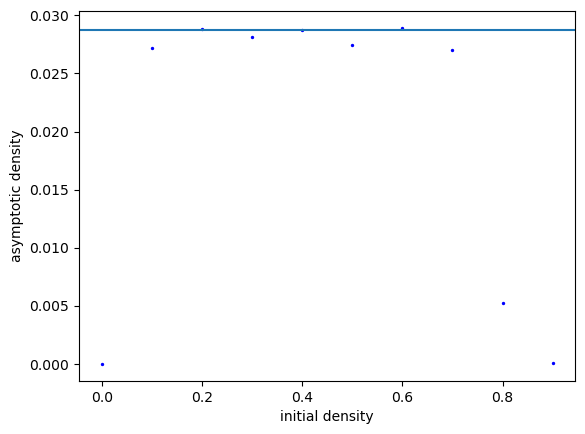

In [10]:
N = 180
T = 9000
trajectories = 7
initial_density = np.arange(0,1,0.1)
asymptotic_density = []
for i_d in initial_density:
    aux_d = 0
    for i in range(trajectories):
        world = world = np.random.random((N,N))
        world[world > i_d] = 0
        world[world != 0] = 1
        for j in range(T):
            world = evolve(world)
        aux_d += (1/trajectories)*np.sum(world==1)/N**2
    asymptotic_density.append(aux_d)
plt.scatter(initial_density, asymptotic_density, s = 2, color = 'blue')
plt.axhline(0.0287)
plt.xlabel('initial density')
plt.ylabel('asymptotic density')
plt.show()

In [16]:
print(asymptotic_density)
plateau = asymptotic_density[2:6]
print(plateau)

[np.float64(0.0), np.float64(0.027200176366843035), np.float64(0.028853615520282188), np.float64(0.02810405643738977), np.float64(0.028783068783068785), np.float64(0.027425044091710756), np.float64(0.028919753086419746), np.float64(0.02702380952380952), np.float64(0.005264550264550263), np.float64(7.936507936507935e-05)]
[np.float64(0.028853615520282188), np.float64(0.02810405643738977), np.float64(0.028783068783068785), np.float64(0.027425044091710756)]


In [12]:
N = 180
T = 9000
trajectories = 7
initial_density = np.arange(0,1,0.01)
asymptotic_density = []
for i_d in initial_density:
    aux_d = 0
    for i in range(trajectories):
        world = world = np.random.random((N,N))
        world[world > i_d] = 0
        world[world != 0] = 1
        for j in range(T):
            world = evolve(world)
        aux_d += (1/trajectories)*np.sum(world==1)/N**2
    asymptotic_density.append(aux_d)

err = np.std(asymptotic_density)
plt.scatter(initial_density, asymptotic_density, s = 2, color = 'blue')
plt.axhline(0.0287)
plt.xlabel('initial density')
plt.ylabel('asymptotic density')
plt.show()

KeyboardInterrupt: 

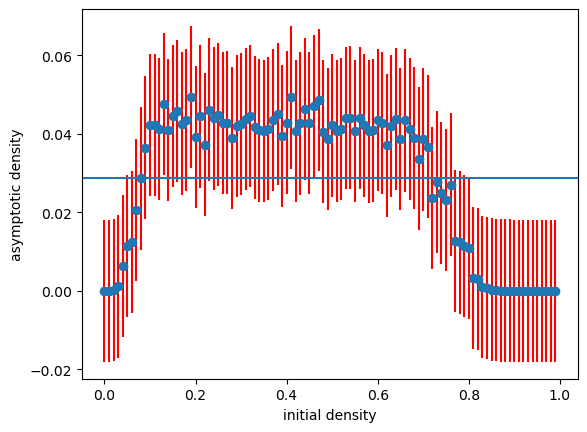

In [11]:
err = np.std(asymptotic_density)
plt.errorbar(initial_density, asymptotic_density, yerr = err, fmt='o', ecolor ='r')
plt.axhline(0.0287)
plt.xlabel('initial density')
plt.ylabel('asymptotic density')
plt.show()

In [13]:
N = 180
T = 2000
trajectories = 7
initial_density = np.arange(0,1,0.01)

asymptotic_density = []
asymptotic_std = []

for i_d in initial_density:
    traj_values = []

    for i in range(trajectories):
        world = (np.random.random((N,N)) < i_d).astype(int)

        for j in range(T):
            new_world = evolve(world)
            if np.array_equal(new_world, world):
                break
            world = new_world

        traj_values.append(np.mean(world))

    asymptotic_density.append(np.mean(traj_values))
    asymptotic_std.append(np.std(traj_values))


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

asymptotic_density = np.array(asymptotic_density)
asymptotic_std = np.array(asymptotic_std)

plt.figure(figsize=(7,5))

plt.errorbar(initial_density,
             asymptotic_density,
             yerr=asymptotic_std,
             fmt='o',
             markersize=3,
             capsize=2,
             label='Simulation')

plt.axhline(0.0287, linestyle='--', label='~0.0287 reference')

plt.xlabel('Initial density')
plt.ylabel('Asymptotic density')
plt.title('Asymptotic density vs initial density\nConway Game of Life')
plt.legend()

plt.tight_layout()
plt.show()


In [7]:
initial_density = 0.4
L = np.array([80,150,300,400])
#L=np.array([50,100])
def count_neighbors(world):
    return ( np.roll(world,1,0) + np.roll(world,-1,0) + np.roll(world,1,1) + np.roll(world,-1,1) +
             np.roll(np.roll(world,1,0),1,1) + np.roll(np.roll(world,1,0),-1,1) + 
             np.roll(np.roll(world,-1,0),1,1) + np.roll(np.roll(world,-1,0),-1,1) )

def evolve(world):
    neighbors = count_neighbors(world)
    new_world = np.zeros(world.shape)
    mask = ( (world==1) & ( (neighbors==2) | (neighbors==3) ) ) | ( (world==0) & (neighbors==3) )
    new_world[mask] = 1
    return new_world

T = 9000
DT = 500
trajectories = 10
time = np.arange(T,T+DT)

#final_d = 0
for l in L:
    print("Lattice size: ", l,"x", l)
    densities = []
    for i in range(trajectories):
        aux_density = []
        world = np.random.random((l,l))
        world[world > initial_density] = 0
        world[world != 0] = 1
        for j in range(T):
            world = evolve(world)
        for j in range(T,T+DT):
            world = evolve(world)
            #final_d += 1/(trajectories*DT)*np.sum(world == 1)/l**2
            aux_density.append(np.sum(world == 1)/l**2)
        densities.append(aux_density)
    densities = np.array(densities)
    print("mean: ", np.mean(densities))
    print("std: ", np.std(densities))

Lattice size:  80 x 80
mean:  0.030171875
std:  0.003930207781164375
Lattice size:  150 x 150
mean:  0.028591111111111116
std:  0.0022951629222140576
Lattice size:  300 x 300
mean:  0.028710000000000003
std:  0.0013040341016521027
Lattice size:  400 x 400



KeyboardInterrupt

